# 图像分类与线性分类器

> **斯坦福 CS231n Lecture 2** | Image Classification with Linear Classifiers

## 本章导读

本节介绍图像分类的核心概念：数据驱动方法、k-NN 的局限性、线性分类器（SVM 和 Softmax）。我们将从手算到代码实现，完整理解线性分类器的工作原理。

**学习目标：**
- 理解图像分类 pipeline
- 掌握 SVM 和 Softmax 损失函数
- 从零实现线性分类器

**参考来源：** [CS231n Linear Classification](https://cs231n.github.io/linear-classify/)

## 1. 直觉理解：图像分类 pipeline

图像分类的核心流程：
```
训练集 → 学习 → 模型参数 (W, b)
测试图像 → 模型 → 预测标签
```

### k-NN 的局限

k-NN 虽然直观，但在高维图像空间中存在严重问题：
- **维度灾难**：高维空间中距离度量失效
- **计算量**：每个测试样本需要与所有训练样本比较
- **无参数学习**：训练数据不压缩为模型参数

### Parametric Approach: Linear Classifier

线性分类器是最简单的参数化模型：
$$f(x_i, W, b) = W x_i + b$$

其中 $x_i \in \mathbb{R}^D$（展平的图像），$W \in \mathbb{R}^{C \times D}$（权重矩阵），$b \in \mathbb{R}^C$（偏置），$C$ 是类别数。

## 2. 手算验证：SVM 损失函数

### Multi-class SVM Loss (Hinge Loss)

对于第 $i$ 个样本，损失为：
$$L_i = \sum_{j \neq y_i} \max(0, s_j - s_{y_i} + 1)$$

其中 $s_j = W_j x_i + b_j$ 是第 $j$ 类的得分，$y_i$ 是真实标签。

### 手算示例

假设 3 个类别，得分 $s = [2.0, 5.0, 1.0]$，真实标签 $y_i = 0$（第 0 类）。

- $j=1$: $\max(0, 5.0 - 2.0 + 1) = 4.0$
- $j=2$: $\max(0, 1.0 - 2.0 + 1) = 0.0$

总损失 $L_i = 4.0 + 0.0 = 4.0$

### Softmax Loss (Cross-Entropy)

$$L_i = -\log\left(\frac{e^{s_{y_i}}}{\sum_j e^{s_j}}\right)$$

对同样的得分：
- $e^{2.0} \approx 7.389$, $e^{5.0} \approx 148.4$, $e^{1.0} \approx 2.718$
- 总和 $\approx 158.5$
- 概率 $p_0 = 7.389 / 158.5 \approx 0.0466$
- 损失 $L_i = -\log(0.0466) \approx 3.06$

In [4]:
# 代码实现：SVM 和 Softmax 损失函数
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

def svm_loss(scores, y):
    """多类 SVM 损失 (Hinge Loss)
    scores: (C,) 得分向量
    y: int 真实标签
    """
    margins = np.maximum(0, scores - scores[y] + 1)
    margins[y] = 0  # 排除正确类别
    return np.sum(margins)

def softmax_loss(scores, y):
    """Softmax 损失 (Cross-Entropy)
    scores: (C,) 得分向量
    y: int 真实标签
    """
    shifted = scores - np.max(scores)  # 数值稳定性
    exp_scores = np.exp(shifted)
    probs = exp_scores / np.sum(exp_scores)
    return -np.log(probs[y])

# 验证手算结果
scores = np.array([2.0, 5.0, 1.0])
y = 0
print(f"SVM 损失: {svm_loss(scores, y):.2f}  (期望: 4.00)")
print(f"Softmax 损失: {softmax_loss(scores, y):.4f}  (期望: ~3.06)")

SVM 损失: 4.00  (期望: 4.00)
Softmax 损失: 3.0659  (期望: ~3.06)


训练准确率: 40.50%


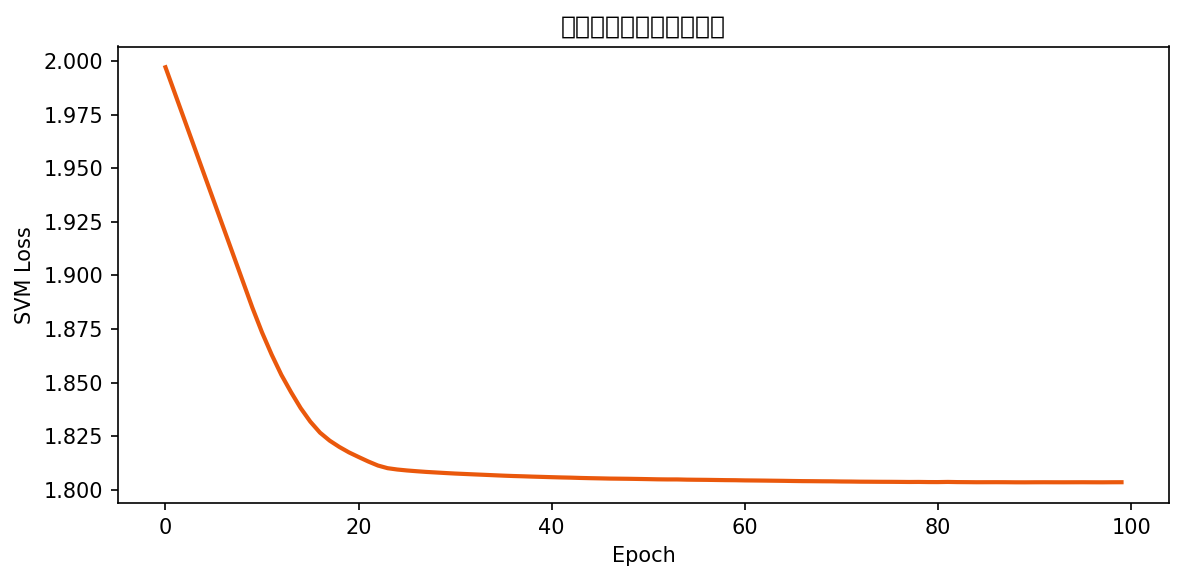

In [5]:
# 完整的线性分类器实现
class LinearClassifier:
    def __init__(self, num_features, num_classes):
        self.W = np.random.randn(num_classes, num_features) * 0.01
        self.b = np.zeros(num_classes)
    
    def forward(self, X):
        return X @ self.W.T + self.b
    
    def svm_loss_grad(self, X, y, reg=1e-3):
        N = X.shape[0]
        scores = self.forward(X)
        margins = np.maximum(0, scores - scores[np.arange(N), y][:, None] + 1)
        margins[np.arange(N), y] = 0
        loss = np.sum(margins) / N + reg * np.sum(self.W ** 2)
        
        # 梯度
        mask = (margins > 0).astype(float)
        mask[np.arange(N), y] = -np.sum(mask, axis=1)
        dW = mask.T @ X / N + 2 * reg * self.W
        db = np.sum(mask, axis=0) / N
        return loss, dW, db
    
    def train(self, X, y, lr=1e-3, reg=1e-3, epochs=100):
        losses = []
        for _ in range(epochs):
            loss, dW, db = self.svm_loss_grad(X, y, reg)
            self.W -= lr * dW
            self.b -= lr * db
            losses.append(loss)
        return losses
    
    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

# 生成合成数据
N, D, C = 200, 4, 3
X = np.random.randn(N, D)
y = np.random.randint(0, C, N)

# 训练
clf = LinearClassifier(D, C)
losses = clf.train(X, y, lr=0.1, epochs=100)
acc = np.mean(clf.predict(X) == y)
print(f"训练准确率: {acc:.2%}")

# 可视化损失曲线
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, color='#ea580c', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('SVM Loss')
ax.set_title('线性分类器训练损失曲线')
plt.tight_layout()
plt.savefig('lecture-02-classification/training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 实验观察：SVM vs Softmax

### 损失函数比较

| 特性 | SVM (Hinge) | Softmax (Cross-Entropy) |
|------|-------------|------------------------|
| **损失值** | $\max(0, s_j - s_{y_i} + 1)$ | $-\log P(y_i)$ |
| **概率输出** | 无 | 有 |
| **梯度** | 稀疏（margin=0 时梯度为0） | 稠密 |
| **对离群点** | 较鲁棒 | 更敏感 |

SVM 的关键特性：一旦正确类别得分比其他类高出 1 以上，该类的损失就为 0，梯度也为 0——模型不再调整。Softmax 则会持续优化，使得概率更接近 1。

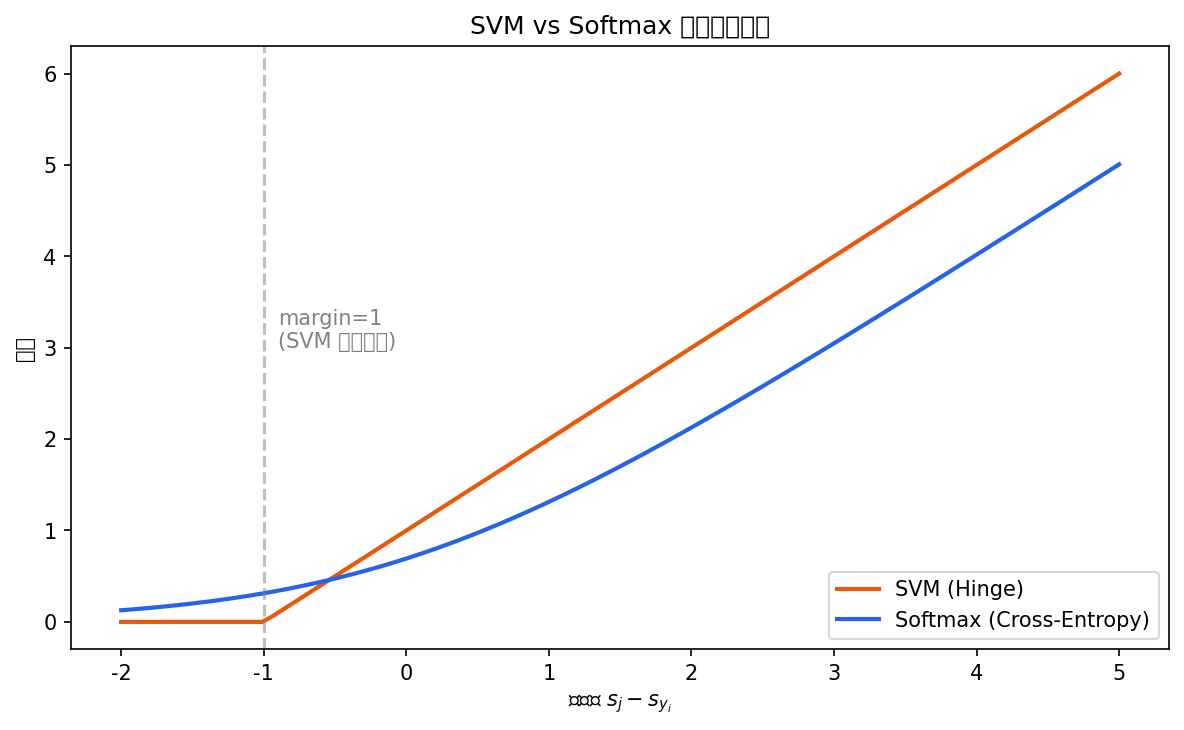

In [7]:
# SVM vs Softmax 损失函数比较
score_gaps = np.linspace(-2, 5, 100)  # s_j - s_{y_i}
svm_losses = np.maximum(0, score_gaps + 1)
softmax_losses = -np.log(np.exp(0) / (np.exp(0) + np.exp(score_gaps)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(score_gaps, svm_losses, label='SVM (Hinge)', color='#ea580c', linewidth=2)
ax.plot(score_gaps, softmax_losses, label='Softmax (Cross-Entropy)', color='#2563eb', linewidth=2)
ax.set_xlabel('得分差 $s_j - s_{y_i}$')
ax.set_ylabel('损失')
ax.set_title('SVM vs Softmax 损失函数比较')
ax.legend()
ax.axvline(x=-1, color='gray', linestyle='--', alpha=0.5)
ax.text(-0.9, 3, 'margin=1\n(SVM 决策边界)', fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('lecture-02-classification/svm_vs_softmax.png', dpi=150, bbox_inches='tight')
plt.show()

## 作业

### 作业 1：实现 Softmax 损失及其梯度

完成以下 Softmax 分类器的训练代码：

In [9]:
# 作业 1：实现 Softmax 损失及梯度
def softmax_loss_and_grad(W, X, y, reg=1e-3):
    """Softmax 损失和梯度
    W: (C, D), X: (N, D), y: (N,)
    返回 loss, dW
    """
    N = X.shape[0]
    scores = X @ W.T  # (N, C)
    # 在此实现 Softmax 损失和梯度
    pass

# 测试
W_test = np.random.randn(3, 4) * 0.01
X_test = np.random.randn(10, 4)
y_test = np.random.randint(0, 3, 10)
loss, dW = softmax_loss_and_grad(W_test, X_test, y_test)
assert loss > 0, "损失应为正数"
assert dW.shape == (3, 4), "梯度形状应与 W 一致"
print("作业 1 通过!")

TypeError: cannot unpack non-iterable NoneType object

## 参考文献

1. **CS231n Linear Classification Notes** - [cs231n.github.io/linear-classify](https://cs231n.github.io/linear-classify/)
2. **CS231n Optimization Notes** - [cs231n.github.io/optimization-1](https://cs231n.github.io/optimization-1/)
3. **Support Vector Machines** - Cortes & Vapnik, 1995.

---

> 本节内容参考 [Stanford CS231n Lecture 2](https://cs231n.stanford.edu/)